# Non-Linear Economy Estimation (ANN)

Please note that this notebook uses a venv which points to a base python version of **3.13**, some functionality may be limited if using an older version of python.

## All Imports

In [1]:
%pip install pandas numpy torch --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
%matplotlib widget

## Data From Source Package

In [3]:
%pip install -e .. --quiet # This is broken for soem reason still, figuring it out

Note: you may need to restart the kernel to use updated packages.


In [4]:
import sys
from pathlib import Path

# repo root is one level above notebooks/
REPO_ROOT = Path.cwd().parent
SRC = REPO_ROOT / "src"

sys.path.insert(0, str(SRC))

import autonomous_fed as afed

In [5]:
solver = afed.EnvironmentSolver(fred_key="7ab121fb17773e187bb6508e83e411da", override_device="cpu")

# Data Check
print (solver.historical_data.head())
print (solver.historical_data.tail())

             pi         y     i
date                           
1987Q3  2.66122 -0.388640  6.84
1987Q4  2.91876  0.526730  6.92
1988Q1  3.06577  0.260731  6.66
1988Q2  3.35274  0.788853  7.16
1988Q3  3.80207  0.595530  7.98
             pi         y     i
date                           
2006Q2  3.35642  1.319357  4.91
2006Q3  3.13805  0.978513  5.25
2006Q4  2.66316  1.380249  5.25
2007Q1  2.91019  1.210046  5.26
2007Q2  2.72883  1.336951  5.25


## Model Architecture

### Single Hidden Layer NARX Model

For our economy transition equations we have: ${y_t=\hat{f}^y(y_{t-1},y_{t-2},\pi_t,\pi_{t-1},\pi_{t-2},i_t,i_{t-1},i_{t-2})+\epsilon_t^y}$ and ${\pi_t=\hat{f}^\pi(y_t,y_{t-1},y_{t-2},\pi_{t-1},\pi_{t-2},i_t,i_{t-1},i_{t-2})+\epsilon_t^\pi}$

In this scenario our predictor function, ${\hat{f}}$ is an ANN (Artificial Neural Network) but it can be swapped with other nonlinear functions such as a sigmoid function or wavelet network. For our ANN predictor we have ${\hat{f}^m=b_0^m+\sum_{j=1}^h v_j^mG(\omega_j^{m'}s_t^m+b_j^m), m\in\{y,\pi}\}$

The Components of the ANN are as follows:
- ${m}$: ${\{y,\pi}\}$
- ${s_t^m}$: Input state vectors at time t.
- ${w_j^m}$: Weight vector for the j-th hidden neuron.
- ${b_j^m}$: Bias term for the current neuron.
- ${G(\cdot)}$: Activation function (nonlinear transform).
- ${v_j^m}$: Weight from hidden neuron ${j}$ to the output layer
- ${b_0^m}$: Bias at the output layer
- ${h}$: Number of hidden neurons.

As seen above the Neural Network type is a NARX Model with a single hidden layer and the activation function is the hyperbolic tangent therefore we define ${G(\cdot)}$ as follows: ${G(x)=tanh(x)=\frac{e^x-e^{-x}}{e^x+e^{-x}}}$

As done in the reference paper the ANNs are intialized with Nguyen-Widrow Initialization. In addition to this we use the Levenberg-Marquardt Algorithm for our optimizer.

### Model Buildout

in the following cells we will replicate the Bundesbank's Neural Net as close as possible by rebuilding some of the MATLAB tools in python for use with PyTorch.

In [6]:
from typing import Iterable, Dict, Union, Tuple, Any, Optional
import random
from dataclasses import dataclass
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.nn.utils import parameters_to_vector, vector_to_parameters
from torch.utils.data import TensorDataset

Below we set the tensor dtype to float64 for pytorch because this model is being run locally on an ARM64 Macbook Pro. We can do training through the GPU by using MPS (Metal Performance Shaders) for our torch device but MPS does not support the float64 dtype only float32. As an effort to better replicate the MATLAB behavior from the reference paper we set dtype to float64 and bound our training to CPU for the torch device.

In [7]:
DTYPE = torch.float64

torch.use_deterministic_algorithms(True)

# (Optional if you ever use CUDA)
# torch.backends.cuda.matmul.allow_tf32 = False
# torch.backends.cudnn.allow_tf32 = False

#### Pre-Tensor-Construction Scaling

Below we imitate MATLAB's data scaling behavior for the NARX Model by using generic linear mapping. For ${X \in{[x_{min},x_{max}]}}$ we map linearly to the new interval $X \in{[a,b]}$ where ${a=-1}$ and ${b=1}$. We achieve this through an affine transformation as follows:

$$
{X \to{a+\frac{b-a}{x_{max}-x_{min}}(X-x_{min})}}
$$

In [8]:
@dataclass
class MapMinMax:
    """
    Min-max scaler mapping features to a target range.

    Attributes:
        in_min (Optional[torch.Tensor]): Minimum values for each feature in the input data.
        in_max (Optional[torch.Tensor]): Maximum values for each feature in the input data.
        out_lo (float): Lower bound of the output range.
        out_hi (float): Upper bound of the output range.
        scale_ (Optional[torch.Tensor]): Scaling factors for each feature.
        mid_ (Optional[torch.Tensor]): Midpoint adjustments for each feature.

    Methods:
        fit: Compute the min and max values for scaling.
        transform: Scale the input data to the specified range.
        inverse_transform: Revert the scaled data back to the original range.
    """
    in_min: Optional[torch.Tensor] = None
    in_max: Optional[torch.Tensor] = None
    out_lo: float = -1.0
    out_hi: float =  1.0
    scale_: Optional[torch.Tensor] = None
    mid_:   Optional[torch.Tensor] = None
    @torch.no_grad()
    def fit(self, X: torch.Tensor) -> "MapMinMax":
        """
        Fit the scaler to the data X.

        Args:
            X (torch.Tensor): Input data to compute min and max values.

        Returns:
            MapMinMax: The fitted scaler instance.

        Raises:
            ValueError: If X is not a 2D tensor.
        """
        if X.ndim != 2:
            raise ValueError("X must be 2-dimensional.")

        # NaN-safe min/max using nan_to_num
        X_min = torch.min(torch.nan_to_num(X, nan=float("inf")), dim=0).values
        X_max = torch.max(torch.nan_to_num(X, nan=-float("inf")), dim=0).values

        # If a column is all-NaN: set min/max = 0 (or choose your default)
        bad = ~torch.isfinite(X_min) | ~torch.isfinite(X_max)
        X_min = torch.where(bad, torch.zeros_like(X_min), X_min)
        X_max = torch.where(bad, torch.zeros_like(X_max), X_max)

        self.in_min = X_min
        self.in_max = X_max

        # Handle constant columns
        rng = self.in_max - self.in_min
        rng_safe = torch.where(rng == 0.0, torch.ones_like(rng), rng)

        # Compute scale + mid
        self.scale_ = (self.out_hi - self.out_lo) / rng_safe
        in_mid  = (self.in_min + self.in_max) * 0.5
        out_mid = (self.out_lo + self.out_hi) * 0.5
        self.mid_ = out_mid - self.scale_ * in_mid

        return self

    def transform(self, X: torch.Tensor) -> torch.Tensor:
        """
        Scale the input data to the specified range.

        Args:
            X (torch.Tensor): Input data to be scaled.

        Returns:
            torch.Tensor: Scaled data.

        Raises:
            ValueError: If the scaler has not been fitted.
        """
        if self.scale_ is None:
            raise ValueError("Scaler not fitted. Call .fit(X) first.")
        return self.scale_ * X + self.mid_

    def inverse_transform(self, Xs: torch.Tensor) -> torch.Tensor:
        """
        Revert the scaled data back to the original range.

        Args:
            Xs (torch.Tensor): Scaled data to be reverted.

        Returns:
            torch.Tensor: Data in the original scale.

        Raises:
            ValueError: If the scaler has not been fitted.
        """
        if self.scale_ is None:
            raise ValueError("Scaler not fitted. Call .fit(X) first.")

        # Prevent div-by-zero
        inv_scale = torch.where(self.scale_ == 0.0,
                                torch.ones_like(self.scale_),
                                self.scale_)

        return (Xs - self.mid_) / inv_scale

#### Nguyen-Widrow Initialization

In our reference paper it is noted that the ANNs are initialized using the Nguyen-Widrow Method. This is done because we are using ${\tanh(x)}$ for our activation function which has saturation zones near -1 and 1. In order to properly replicate the paper and ensure neurons are placed in the high-information region of the activation function,we build a Nguyen-Widrow Initializer as follows:

$$
{w_i=\beta\times\frac{w_i^0}{||w_i^0||}, b_i~U[-\beta,\beta], \beta=0.7n_{out}^{1/n_{in}}}
$$


In [9]:
@torch.no_grad()
def nguyen_widrow_(layer: nn.Linear) -> None:
    """
    Nguyen-Widrow initialization for a single linear layer feeding a tanh/sigmoid block. Scales incoming weight vectors to beta = 0.7 * (n_out)^(1/n_in). Bias in [-beta, beta].
    
    Args:
        layer (nn.Linear): Linear layer to initialize.

    Returns:
        None

    Raises:
        None
    """
    n_out, n_in = layer.weight.shape
    with torch.no_grad():
        W = torch.empty_like(layer.weight).uniform_(-0.5, 0.5)
        norms = torch.norm(W, dim=1, keepdim=True).clamp_min(1e-12)
        W = W / norms
        beta = 0.7 * (n_out ** (1.0 / n_in))
        layer.weight.copy_(W * beta)
        layer.bias.uniform_(-beta, beta)

#### Levenberg-Marquardt Optimizer

In the Bundesbank paper, in addition to the Nguyen Widrow Initializer, the networks are trained using the Levenberg-Marquardt Algorithm, thus we build an optimizer to mimic this behavior.

In [10]:
class LevenbergMarquardt(torch.optim.Optimizer):
    """
    Implements the Levenberg-Marquardt optimization algorithm for non-linear least squares problems.

    Attributes:
        params (Iterable[torch.nn.Parameter]): Iterable of parameters to optimize.
        mu (float): Initial damping factor.
        mu_lo (float): Minimum damping factor.
        mu_hi (float): Maximum damping factor.
        mu_up (float): Factor to increase mu when step is rejected.
        mu_down (float): Factor to decrease mu when step is accepted.
        weight_decay (float): Weight decay (L2 penalty) coefficient.

    Methods:
        step(closure): Performs a single optimization step.
    """
    def __init__(self, 
                 params: Iterable[torch.nn.Parameter], 
                 mu: float=1e-3, 
                 mu_lo: float=1e-12, 
                 mu_hi: float=1e10, 
                 mu_up: float=10.0, 
                 mu_down: float=0.1, 
                 weight_decay: float=0.0) -> None:
        """
        Initializes the Levenberg-Marquardt optimizer.

        Args:
            params (Iterable[torch.nn.Parameter]): Iterable of parameters to optimize.
            mu (float, optional): Initial damping factor. Default is 1e-3.
            mu_lo (float, optional): Minimum damping factor. Default is 1e-12
            mu_hi (float, optional): Maximum damping factor. Default is 1e10.
            mu_up (float, optional): Factor to increase mu when step is rejected. Default is 10.0.
            mu_down (float, optional): Factor to decrease mu when step is accepted. Default is 0.1.
            weight_decay (float, optional): Weight decay (L2 penalty) coefficient. Default is 0.0.

        Returns:
            None

        Raises:
            ValueError: If any of the hyperparameters are out of valid range.
        """
        defaults = dict(mu=mu, mu_lo=mu_lo, mu_hi=mu_hi, mu_up=mu_up, mu_down=mu_down, weight_decay=weight_decay)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure: callable) -> Dict[str, Union[float, bool]]:
        """
        Performs a single optimization step using the Levenberg-Marquardt algorithm.

        Args:
            closure (callable): A closure that reevaluates the model and returns the residuals.

        Returns:
            Dict: A dictionary containing information about the optimization step:
                - "rho": Gain ratio (float).
                - "accepted": Whether the step was accepted (bool).
                - "mu": Updated damping factor (float).
                - "old_sse": Sum of squared errors before the step (float).
                - "new_sse": Sum of squared errors after the step (float).

        Raises:
            RuntimeError: If the linear system cannot be solved.
        """
        # Flatten parameters
        params = []
        for group in self.param_groups:
            for p in group['params']:
                if p.requires_grad:
                    params.append(p)
        theta = parameters_to_vector(params)
        P = theta.numel()

        # Compute residuals r(theta)
        r = closure() # 1D vector (M,)
        if r.dim() > 1:
            r = r.reshape(-1)
        M = r.numel()

        # Build J explicitly (M x P) by autograd on each residual entry
        # NOTE: This is slow; fine for small M,P only.
        J = torch.zeros(M, P, dtype=theta.dtype, device=theta.device)
        # We need a graph for grads w.r.t. params
        # Recompute r with graph (not no_grad)
        with torch.enable_grad():
            # Recompute r with graph
            rr = closure()
            rr = rr.reshape(-1)
            for i in range(M):
                self.zero_grad(set_to_none=True)
                grad_i = torch.autograd.grad(rr[i], params, retain_graph=True, allow_unused=False)
                J[i] = parameters_to_vector(grad_i)

        # Form normal equations: (J^T J + mu I) Δ = -J^T r
        group = self.param_groups[0]
        mu = group['mu']
        wd = group['weight_decay']

        JT = J.transpose(0, 1) # P x M
        JTJ = JT @ J # P x P
        if wd != 0.0:
            JTJ = JTJ + wd * torch.eye(P, device=theta.device, dtype=theta.dtype)
        rhs = -(JT @ r) # P

        A = JTJ + mu * torch.eye(P, device=theta.device, dtype=theta.dtype)
        # Solve
        try:
            dtheta = torch.linalg.solve(A, rhs)
        except RuntimeError:
            # fallback to least-squares
            dtheta, *_ = torch.linalg.lstsq(A, rhs.unsqueeze(1))
            dtheta = dtheta.squeeze(1)

        # Evaluate gain ratio ρ to adapt mu
        old_r = r
        old_sse = 0.5 * (old_r @ old_r)

        # Canonical LM quantities BEFORE updating parameters
        g = JT @ old_r # gradient (P,)
        predicted_reduction = 0.5 * (dtheta @ (mu * dtheta - g))

        # If model predicts no reduction (numerical or negative), force μ increase
        if predicted_reduction <= 0:
            rho = -1.0
            # Reject immediately: increase μ and keep params
            new_mu = min(group['mu_hi'], max(group['mu_lo'], mu * group['mu_up']))
            group['mu'] = new_mu
            return {
                "rho": float(rho),
                "accepted": False,
                "mu": float(group['mu']),
                "old_sse": float(old_sse.item()),
                "new_sse": float(old_sse.item())
            }

        # Tentative update
        new_theta = theta + dtheta
        old_params = theta.clone()
        vector_to_parameters(new_theta, params)

        new_r = closure().reshape(-1)
        new_sse = 0.5 * (new_r @ new_r)

        rho = (old_sse - new_sse) / predicted_reduction

        if rho > 0 and new_sse < old_sse: # accept
            new_mu = min(group['mu_hi'], max(group['mu_lo'], mu * group['mu_down']))
            group['mu'] = new_mu
            success = True
        else: # reject
            vector_to_parameters(old_params, params)
            new_mu = min(group['mu_hi'], max(group['mu_lo'], mu * group['mu_up']))
            group['mu'] = new_mu
            success = False
            new_sse = old_sse # report unchanged SSE

        return {
            "rho": float(rho.item()),
            "accepted": success,
            "mu": float(group['mu']),
            "old_sse": float(old_sse.item()),
            "new_sse": float(new_sse.item())
        }

#### Single Hidden Layer Artificial Neural Network

Below we mimic the refernce paper's Single-hidden-layer Artificial Neural Network with n-hidden nodes, ${\tanh(x)}$ activation function, and Nguyen-Widrow initialization.

In [11]:
class SingleHiddenLayerNet(nn.Module):
    """
    Single hidden layer neural network.
    
    Attributes:
        h (nn.Linear): Hidden layer.
        o (nn.Linear): Output layer.

    Methods:
        forward: Forward pass through the network.
    """
    def __init__(self, n_in: int, n_hidden: int, n_out: int) -> None:
        super().__init__()
        self.h = nn.Linear(n_in, n_hidden)
        nguyen_widrow_(self.h) # only hidden layer
        self.o = nn.Linear(n_hidden, n_out)
        # Small random init for output layer (paper-style)
        bound = 0.03
        nn.init.uniform_(self.o.weight, -bound, bound)
        nn.init.uniform_(self.o.bias, -bound, bound)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass through the network.
        
        Args:
            x (torch.Tensor): Input tensor.

        Returns:
            torch.Tensor: Output tensor after passing through the network.

        Raises:
            None
        """
        if x.dtype != self.h.weight.dtype:
            x = x.to(self.h.weight.dtype)
        return self.o(torch.tanh(self.h(x)))

#### Lagged Data Matrix

The following function takes our economic series DataFrame and turns it into a supervised learning matrix with specific lags to mimic our NARX structure with $[-1,1]$ scaled data and a 85% train + 15% validation split as specified by the reference paper.

In [12]:
def make_lag_matrix(
                    df: pd.DataFrame,
                    target_col: str,
                    holdout_frac: float=0.15,
                    feature_range: Tuple[float, float]=(-1.0, 1.0)) -> Tuple[TensorDataset, TensorDataset, Dict[str, Any]]:
    """
    Constructs lagged input-output data matrices for time series modeling.

    Args:
        df (pd.DataFrame): DataFrame containing the time series data.
        target_col (str): Name of the target column to predict. Must be either 'y' or 'pi'.
        holdout_frac (float, optional): Fraction of data to hold out for validation. Default is 0.15.
        feature_range (Tuple[float, float], optional): Desired range of transformed features. Default is (-1.0, 1.0).

    Returns:
        Tuple[TensorDataset, TensorDataset, Dict[str, Any]]: Training and validation datasets as TensorDataset objects.

    Raises:
        ValueError: If target_col is not 'y' or 'pi', or if required columns are missing.
    """
    required = {"y", "pi", "i"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"DataFrame missing required columns: {missing}")

    data = df.copy().sort_index()

    # Create needed lags
    data["y_lag1"]  = data["y"].shift(1)
    data["y_lag2"]  = data["y"].shift(2)
    data["pi_lag1"] = data["pi"].shift(1)
    data["pi_lag2"] = data["pi"].shift(2)
    data["i_lag1"]  = data["i"].shift(1)
    data["i_lag2"]  = data["i"].shift(2)

    if target_col == "y":
        feature_cols = [
            "y_lag1",
            "pi_lag1",
            "i_lag1",
            "i_lag2"
        ]
        y_series = data["y"]
    elif target_col == "pi":
        feature_cols = [
            "y",
            "y_lag1",
            "y_lag2",
            "pi_lag1",
            "pi_lag2",
            "i_lag1"
        ]
        y_series = data["pi"]
    else:
        raise ValueError("target_col must be 'y' or 'pi' for enforced paper design.")

    x_df = data[feature_cols]
    mask = x_df.notna().all(axis=1) & y_series.notna()

    # still build via NumPy, then convert once to torch
    x_np = x_df[mask].values.astype(np.float64)
    y_np = y_series[mask].values.astype(np.float64).reshape(-1, 1)

    # deterministic “last 15%” validation split
    n_total = len(x_np)
    n_hold  = int(np.floor(holdout_frac * n_total))
    n_train = n_total - n_hold

    xtr_raw_np, xva_raw_np = x_np[:n_train], x_np[n_train:]
    ytr_raw_np, yva_raw_np = y_np[:n_train], y_np[n_train:]

    # --- CONVERT TO TENSORS BEFORE SCALING (torch-native path) ---
    xtr_raw = torch.as_tensor(xtr_raw_np, dtype=DTYPE)
    xva_raw = torch.as_tensor(xva_raw_np, dtype=DTYPE)
    ytr_raw = torch.as_tensor(ytr_raw_np, dtype=DTYPE)
    yva_raw = torch.as_tensor(yva_raw_np, dtype=DTYPE)

    # fit scalers on TRAIN ONLY (tensors in, tensors out)
    x_scaler = MapMinMax(out_lo=feature_range[0],
                        out_hi=feature_range[1]).fit(xtr_raw)
    y_scaler = MapMinMax(out_lo=feature_range[0],
                        out_hi=feature_range[1]).fit(ytr_raw)

    # scaled tensors (no .astype, no from_numpy)
    xtr = x_scaler.transform(xtr_raw)  # torch.Tensor
    xva = x_scaler.transform(xva_raw)  # torch.Tensor
    ytr = y_scaler.transform(ytr_raw)  # torch.Tensor
    yva = y_scaler.transform(yva_raw)  # torch.Tensor

    # ensure dtype
    xtr = xtr.to(DTYPE)
    xva = xva.to(DTYPE)
    ytr = ytr.to(DTYPE)
    yva = yva.to(DTYPE)

    # TensorDatasets directly from tensors
    train_ds = TensorDataset(xtr, ytr)
    val_ds   = TensorDataset(xva, yva)

    meta = {
        "feature_cols": feature_cols,
        "x_scaler": x_scaler,
        "y_scaler": y_scaler,
        "xtr_raw": xtr_raw,
        "xva_raw": xva_raw,
        "ytr_raw": ytr_raw,
        "yva_raw": yva_raw,
    }
    return train_ds, val_ds, meta

#### Training Function

In [13]:
def train_one_run_LM(model: nn.Module, train_ds: TensorDataset, val_ds: TensorDataset, max_epochs: int=200, patience: int=6, mu_init: float=1e-3) -> Tuple[float, nn.Module]:
    """
    Trains a neural network model using the Levenberg-Marquardt optimization algorithm with early stopping based on validation loss.

    Args:
        model (nn.Module): Neural network model to train.
        train_ds (TensorDataset): Training dataset.
        val_ds (TensorDataset): Validation dataset.
        max_epochs (int, optional): Maximum number of training epochs. Default is 200.
        patience (int, optional): Number of epochs to wait for improvement before early stopping. Default is 25.
        mu_init (float, optional): Initial damping factor for LM optimizer. Default is 1e-3.

    Returns:
        Tuple[float, nn.Module]: Best validation MSE and the trained model.

    Raises:
        None
    """
    Xtr, ytr = train_ds.tensors
    Xva, yva = val_ds.tensors
    model = model.to(DTYPE)
    
    # Levenberg–Marquardt optimizer instance
    opt = LevenbergMarquardt(model.parameters(), mu=mu_init)
    loss_fn = torch.nn.MSELoss()
    
    best = {"val": float("inf"), "state": None, "epoch": -1}
    bad_epochs = 0
    
    # LM closure returning residual vector (NOT scalar loss)
    def closure_train():
        model.zero_grad(set_to_none=True)
        pred = model(Xtr)
        r = (pred - ytr).reshape(-1)
        return r
    
    for ep in range(max_epochs):
        # One LM parameter update
        info = opt.step(closure_train)
        
        # Evaluate on validation set
        model.eval()
        with torch.no_grad():
            val_pred = model(Xva)
            val_mse = loss_fn(val_pred, yva).item()
        
        # Early stopping logic
        if val_mse < best["val"] - 1e-8:
            best.update(state={k: v.clone() for k, v in model.state_dict().items()},
                        val=val_mse, epoch=ep)
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                break

        # Optional monitoring
        if (ep+1) % 10 == 0:
            print(f"Epoch {ep+1:03d}: val={val_mse:.6f}, μ={info['mu']:.2e}, accepted={info['accepted']}")
    
    # Restore best parameters
    if best["state"] is not None:
        model.load_state_dict(best["state"])
    
    return best["val"], model

#### Hidden Search Function:

In [14]:
def search_hidden_units_LM(df: pd.DataFrame, target_col: str, hidden_grid: range = range(1, 11), seeds: int=30, holdout_frac: float=0.15) -> Dict[str, Union[float, int, nn.Module]]:
    """
    Searches for the optimal number of hidden units in a single hidden layer neural network using the Levenberg-Marquardt optimization algorithm.

    Args:
        df (pd.DataFrame): DataFrame containing the time series data.
        target_col (str): Name of the target column to predict. Must be either 'y' or 'pi'.
        hidden_grid (range, optional): Range of hidden units to search over. Default is range(1, 11).
        seeds (int, optional): Number of random initializations per hidden unit setting. Default is 30.
        holdout_frac (float, optional): Fraction of data to hold out for validation. Default is 0.15.

    Returns:
        Dict[str, Union[float, int, nn.Module]]: Dictionary containing the best overall
            - "metric": Best validation MSE (float).
            - "h": Number of hidden units for the best model (int).
            - "model": The best trained model (nn.Module).

    Raises:
        ValueError: If target_col is not 'y' or 'pi', or if required columns are missing.
    """
    overall = {"metric": float("inf")}
    per_h_stats = []
    for h in hidden_grid:
        mses, runs = [], []

        for s in range(seeds):
            seed = 10_000 + 97*h + s
            torch.manual_seed(seed)
            np.random.seed(seed)
            random.seed(seed)
            
            train_ds, val_ds, meta = make_lag_matrix(
                df, target_col=target_col, holdout_frac=holdout_frac
            )
            n_in = train_ds.tensors[0].shape[1]
            
            model = SingleHiddenLayerNet(n_in=n_in, n_hidden=h, n_out=1).to(dtype=DTYPE)
            
            val_mse, fitted = train_one_run_LM(model, train_ds, val_ds)
            mses.append(val_mse)
            runs.append((val_mse, fitted, meta))
        mean_mse = float(np.mean(mses))
        per_h_stats.append((h, mean_mse, mses))
        if mean_mse < overall["metric"]:
            # pick the single best run *within this h* to keep
            best_run = min(runs, key=lambda t: t[0])
            overall = {
                "metric": mean_mse, 
                "h": h, 
                "model": best_run[1],
                "meta": best_run[2]
            }
    
    print("\n=== Overall Best ===")
    print(f"h = {overall['h']},  val MSE = {overall['metric']:.6f}")
    return overall

#### Predict

In [15]:
@torch.no_grad()
def predict(model: nn.Module, X_raw: torch.Tensor, x_scaler: MapMinMax, y_scaler: MapMinMax, device: str="cpu") -> np.ndarray:
    """
    Predict using the model and inverse transform the output to the original scale.

    Args:
        model (nn.Module): Trained PyTorch model.
        X_raw (torch.Tensor): Raw input features (unscaled), shape (N, n_in).
        x_scaler (MapMinMax): Scaler for input features.
        y_scaler (MapMinMax): Scaler for output.
        device (str, optional): Device to run the model on. Default is "cpu".

    Returns:
        np.ndarray: Predicted values in the original scale (1D array for convenience).

    Raises:
        None
    """
    # ensure proper dtype/device
    X_raw = X_raw.to(dtype=DTYPE, device=device)

    # scale inputs (torch-native)
    Xs = x_scaler.transform(X_raw) # torch.Tensor

    # model forward
    model = model.to(dtype=DTYPE, device=device)
    yhat_s = model(Xs) # scaled predictions (tensor)

    # inverse scale
    yhat = y_scaler.inverse_transform(yhat_s) # tensor in original scale

    # return NumPy for plots/etc.
    return yhat.detach().cpu().numpy().reshape(-1)

### Scale, Train, Search, and Invert 

In [16]:
best_y  = search_hidden_units_LM(solver.historical_data, target_col='y')
best_pi = search_hidden_units_LM(solver.historical_data, target_col='pi')

Epoch 010: val=0.014635, μ=1.00e-03, accepted=True
Epoch 010: val=0.024803, μ=1.00e-01, accepted=False
Epoch 010: val=0.013234, μ=1.00e-07, accepted=True
Epoch 010: val=0.013181, μ=1.00e-03, accepted=True
Epoch 010: val=0.013228, μ=1.00e-05, accepted=True
Epoch 010: val=0.014046, μ=1.00e-05, accepted=True
Epoch 010: val=0.013234, μ=1.00e-07, accepted=True
Epoch 010: val=0.013234, μ=1.00e-09, accepted=True
Epoch 010: val=0.013235, μ=1.00e-07, accepted=True
Epoch 010: val=0.013179, μ=1.00e-05, accepted=True
Epoch 010: val=0.013234, μ=1.00e-09, accepted=True
Epoch 010: val=0.025783, μ=1.00e-03, accepted=True
Epoch 020: val=0.013234, μ=1.00e-09, accepted=True
Epoch 010: val=0.013234, μ=1.00e-07, accepted=True
Epoch 010: val=0.012751, μ=1.00e-03, accepted=True
Epoch 010: val=0.015517, μ=1.00e-01, accepted=True
Epoch 020: val=0.014104, μ=1.00e-01, accepted=True
Epoch 010: val=0.013233, μ=1.00e-05, accepted=True
Epoch 010: val=0.012844, μ=1.00e-03, accepted=True
Epoch 010: val=0.013232, μ=1.0

In [17]:
y_meta = best_y["meta"]
pi_meta = best_pi["meta"]

print(f"Best y model has {best_y['h']} hidden units with val MSE = {best_y['metric']:.6f}")
print(f"Best pi model has {best_pi['h']} hidden units with val MSE = {best_pi['metric']:.6f}")

Best y model has 3 hidden units with val MSE = 0.017889
Best pi model has 3 hidden units with val MSE = 0.028609


In [18]:
device = "cpu"
yhat_val  = predict(best_y["model"],  y_meta["xva_raw"],  y_meta["x_scaler"],  y_meta["y_scaler"],  device=device)
pihat_val = predict(best_pi["model"], pi_meta["xva_raw"], pi_meta["x_scaler"], pi_meta["y_scaler"], device=device)

print("Validation Predictions for y:")
print(yhat_val)
print("Validation Predictions for pi:")
print(pihat_val)

Validation Predictions for y:
[0.22798895 0.59644527 0.9705836  0.87002573 1.00964865 0.9905551
 1.39452228 1.27247242 1.05922245 1.23553917 1.14854369]
Validation Predictions for pi:
[2.79982657 2.94973553 3.11544009 2.91394555 3.23883043 3.1928149
 3.37540501 3.34491869 3.04192713 2.75694818 2.84986038]


#### Full Data Matrix

We create the following function to capture the entire dataset for running the ANN with the optimal number of hidden units now that the search ahs been performed.

In [19]:
def build_full_design(df: pd.DataFrame, target_col: str) -> Tuple[torch.Tensor, torch.Tensor, pd.Index]:
    """
    Rebuild the same lag structure as make_lag_matrix, but for the
    entire sample (no train/val split). Returns:
        X_raw  : torch.Tensor (N, n_features)
        y_true : torch.Tensor (N, 1)
        idx    : index aligned with rows
    """
    data = df.copy().sort_index()

    required = {"y", "pi", "i"}
    missing = required - set(data.columns)
    if missing:
        raise ValueError(f"DataFrame missing required columns: {missing}")

    # Create the same lags as in make_lag_matrix
    data["y_lag1"]  = data["y"].shift(1)
    data["y_lag2"]  = data["y"].shift(2)
    data["pi_lag1"] = data["pi"].shift(1)
    data["pi_lag2"] = data["pi"].shift(2)
    data["i_lag1"]  = data["i"].shift(1)
    data["i_lag2"]  = data["i"].shift(2)

    if target_col == "y":
        feature_cols = [
            "y_lag1",
            "pi_lag1",
            "i_lag1",
            "i_lag2",
        ]
        y_series = data["y"]
    elif target_col == "pi":
        feature_cols = [
            "y",
            "y_lag1",
            "y_lag2",
            "pi_lag1",
            "pi_lag2",
            "i_lag1",
        ]
        y_series = data["pi"]
    else:
        raise ValueError("target_col must be 'y' or 'pi'.")

    x_df = data[feature_cols]
    mask = x_df.notna().all(axis=1) & y_series.notna()

    X_np = x_df[mask].values.astype(np.float64)
    y_np = y_series[mask].values.astype(np.float64).reshape(-1, 1)
    idx  = data.index[mask]

    X_raw  = torch.as_tensor(X_np, dtype=DTYPE)
    y_true = torch.as_tensor(y_np, dtype=DTYPE)

    return X_raw, y_true, idx

### Figure 4 Output Gap Fit: Squared Errors (Replication)

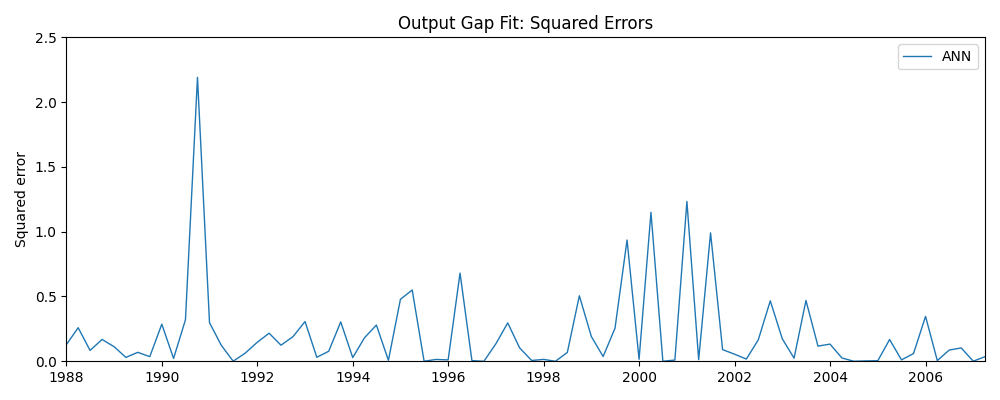

In [20]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# === 1. Build full design for y ===
X_full_y_raw, y_full_y, idx_full_y = build_full_design(
    solver.historical_data, target_col="y"
)

# Convert PeriodIndex to timestamps if needed (for plotting)
if isinstance(idx_full_y, pd.PeriodIndex):
    idx_plot = idx_full_y.to_timestamp()
else:
    idx_plot = pd.to_datetime(idx_full_y)

# === 2. ANN fitted values on full sample ===
y_full_true = y_full_y.detach().cpu().numpy().reshape(-1)

y_full_hat_ann = predict(
    best_y["model"],
    X_full_y_raw,
    y_meta["x_scaler"],   # scalers from training
    y_meta["y_scaler"],
    device="cpu"
)

sq_err_ann = (y_full_true - y_full_hat_ann) ** 2

# === 3. Plot, Figure-4 style ===
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(idx_plot, sq_err_ann, label="ANN", linewidth=1)

ax.set_title("Output Gap Fit: Squared Errors")
ax.set_ylabel("Squared error")
ax.set_xlabel("")
ax.set_ylim(0, 2.5)

ax.set_xlim(idx_plot[0], idx_plot[-1])
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

### Figure 5 Inflation Fit: Squared Errors (Replication)

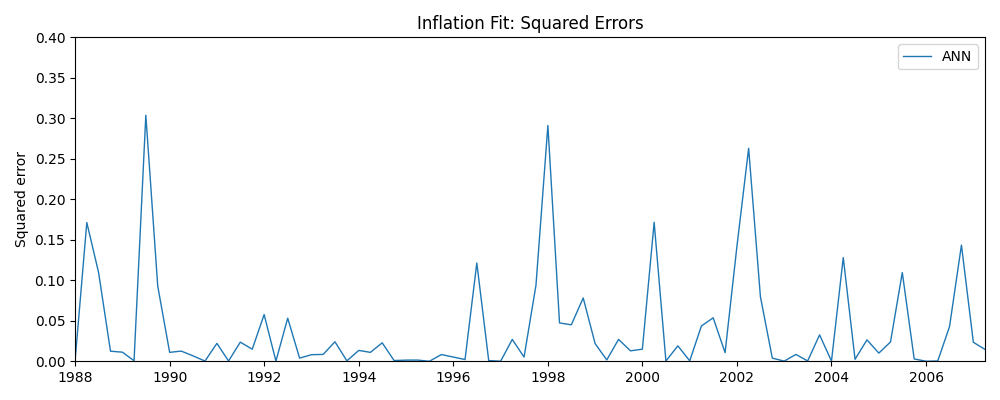

In [21]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# === 1. Build full design for pi ===
X_full_pi_raw, pi_full, idx_full_pi = build_full_design(
    solver.historical_data, target_col="pi"
)

# Convert PeriodIndex to timestamps if needed (for plotting)
if isinstance(idx_full_pi, pd.PeriodIndex):
    idx_plot_pi = idx_full_pi.to_timestamp()
else:
    idx_plot_pi = pd.to_datetime(idx_full_pi)

# === 2. ANN fitted values on full sample ===
pi_full_true = pi_full.detach().cpu().numpy().reshape(-1)

pi_full_hat_ann = predict(
    best_pi["model"],
    X_full_pi_raw,
    pi_meta["x_scaler"],   # scalers from training (pi)
    pi_meta["y_scaler"],
    device="cpu"
)

sq_err_ann_pi = (pi_full_true - pi_full_hat_ann) ** 2

# === 3. Plot, Figure-4 style ===
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(idx_plot_pi, sq_err_ann_pi, label="ANN", linewidth=1)

ax.set_title("Inflation Fit: Squared Errors")
ax.set_ylabel("Squared error")
ax.set_xlabel("")

# Optional: match your y-plot styling
ax.set_ylim(0, 0.4)

ax.set_xlim(idx_plot_pi[0], idx_plot_pi[-1])
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

### Table 3 Economy Fit: Mean Squared Errors

In [22]:
from IPython.display import Markdown, display

svar_y_msq = solver.squared_errors_data["se_y_svar"].mean()
svar_pi_msq = solver.squared_errors_data["se_pi_svar"].mean()
ann_y_msq = np.mean(sq_err_ann)
ann_pi_msq = np.mean(sq_err_ann_pi)

table_three_str = fr"""
| Representation | MSE Output Gap   | MSE Inflation     | MSE Total                        |
|----------------|------------------|-------------------|----------------------------------|
| SVAR           | {svar_y_msq:.3f} | {svar_pi_msq:.3f} | {(svar_pi_msq+svar_y_msq)/2:.3f} |
| ANN            | {ann_y_msq:.3f}  | {ann_pi_msq:.3f}  | {(ann_y_msq+ann_pi_msq)/2:.3f}   |
"""

display(Markdown(table_three_str))


| Representation | MSE Output Gap   | MSE Inflation     | MSE Total                        |
|----------------|------------------|-------------------|----------------------------------|
| SVAR           | 0.211 | 0.032 | 0.122 |
| ANN            | 0.209  | 0.041  | 0.125   |


### PDP Functions

In [33]:
import numpy as np
import torch
import matplotlib.pyplot as plt

@torch.no_grad()
def pd_surface_constrained(
    model,
    X_raw: torch.Tensor,        # (N,p) unscaled, original units
    x_scaler,
    y_scaler,
    feature_cols: list[str],
    grid_x_feat: str,
    grid_y_feat: str,
    grid_x_n: int = 25,
    grid_y_n: int = 25,
    q_low: float = 0.02,
    q_high: float = 0.98,
    sample: int | None = 2000,
    tie_groups: list[tuple[str, ...]] | None = None,
    device: str = "cpu",
):
    """
    Partial dependence surface with equality constraints.
    - grid_x_feat and grid_y_feat are the two "axis" variables.
    - tie_groups enforces equalities:
        * If a group contains a grid feature -> all in that group set to the grid value.
        * If a group contains no grid feature -> set all members equal ROW-WISE to the first member.
          (This matches "assume a=b" while still marginalizing over the distribution of 'a'.)
    Returns: gx, gy, Z (Z shape: (len(gy), len(gx)))
    """
    tie_groups = tie_groups or []

    # Subsample for speed (still valid: PDP is an average over rows)
    X0 = X_raw
    N = X0.shape[0]
    if sample is not None and sample < N:
        idx = torch.randperm(N)[:sample]
        X0 = X0[idx]

    def col_idx(name: str) -> int:
        if name not in feature_cols:
            raise ValueError(f"{name} not in feature_cols: {feature_cols}")
        return feature_cols.index(name)

    ix = col_idx(grid_x_feat)
    iy = col_idx(grid_y_feat)

    x_vals = X0[:, ix].detach().cpu().numpy()
    y_vals = X0[:, iy].detach().cpu().numpy()
    lo_x, hi_x = np.quantile(x_vals, [q_low, q_high])
    lo_y, hi_y = np.quantile(y_vals, [q_low, q_high])

    gx = np.linspace(lo_x, hi_x, grid_x_n)
    gy = np.linspace(lo_y, hi_y, grid_y_n)

    model = model.to(device=device, dtype=X0.dtype)
    X0 = X0.to(device=device, dtype=X0.dtype)

    # Precompute tie indices
    tie_idx_groups = []
    for g in tie_groups:
        tie_idx_groups.append([col_idx(n) for n in g])

    Z = np.zeros((grid_y_n, grid_x_n), dtype=np.float64)

    for j, yv in enumerate(gy):
        for i, xv in enumerate(gx):
            Xg = X0.clone()

            # Set the grid axes
            Xg[:, ix] = float(xv)
            Xg[:, iy] = float(yv)

            # Enforce tie constraints
            for g_idx in tie_idx_groups:
                # If group includes an axis feature, tie all to that axis value
                if ix in g_idx:
                    for k in g_idx:
                        Xg[:, k] = float(xv)
                elif iy in g_idx:
                    for k in g_idx:
                        Xg[:, k] = float(yv)
                else:
                    # Row-wise tie to the first column in the group
                    base_col = g_idx[0]
                    for k in g_idx[1:]:
                        Xg[:, k] = Xg[:, base_col]

            # Predict, then average over rows (marginalization)
            Xs = x_scaler.transform(Xg)
            yhat_s = model(Xs)
            yhat = y_scaler.inverse_transform(yhat_s)
            Z[j, i] = float(yhat.mean().detach().cpu().item())

    return gx, gy, Z


def plot_surface(gx, gy, Z, xlabel, ylabel, zlabel, title):
    X, Y = np.meshgrid(gx, gy)
    fig = plt.figure(figsize=(8, 5.5))
    ax = fig.add_subplot(111, projection="3d")
    ax.plot_surface(X, Y, Z, cmap="viridis", linewidth=0.2, antialiased=True)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_zlabel(zlabel)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

#### Figure 6: Partial Dependence Surface Plot - ANN Economy, Inflation

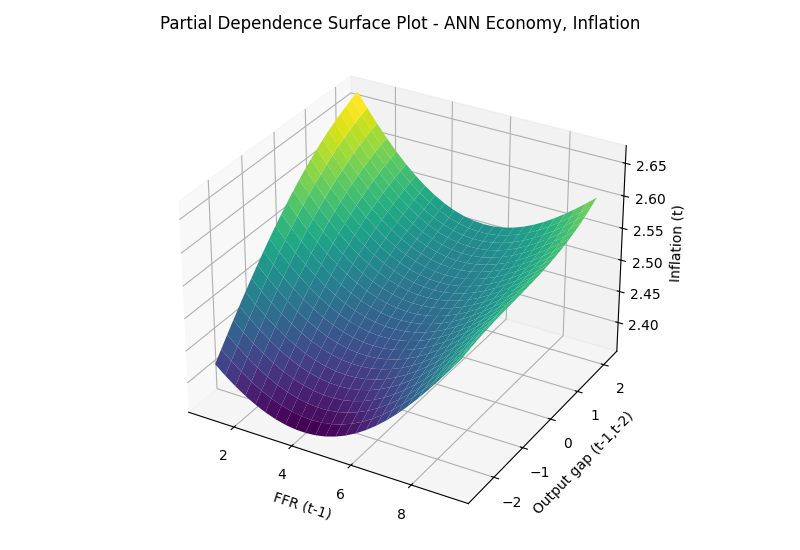

In [27]:
# Inflation surface: pi_hat = f(y, y_lag1, y_lag2, pi_lag1, pi_lag2, i_lag1)
# Match paper constraints:
#   y = y(t-1) = y(t-2)
#   pi(t-1) = pi(t-2)
gx, gy, Z = pd_surface_constrained(
    model=best_pi["model"],
    X_raw=X_full_pi_raw,
    x_scaler=pi_meta["x_scaler"],
    y_scaler=pi_meta["y_scaler"],
    feature_cols=pi_meta["feature_cols"],
    grid_x_feat="i_lag1",      # FFR (t-1)
    grid_y_feat="y_lag1",      # Output gap (t-1) (also ties to y_lag2 and y)
    grid_x_n=25,
    grid_y_n=25,
    sample=2500,
    tie_groups=[
        ("y", "y_lag1", "y_lag2"),      # enforce y=y(t-1)=y(t-2)
        ("pi_lag1", "pi_lag2"),         # enforce pi(t-1)=pi(t-2) row-wise
    ],
    device="cpu",
)

plot_surface(
    gx, gy, Z,
    xlabel="FFR (t-1)",
    ylabel="Output gap (t-1,t-2)",
    zlabel="Inflation (t)",
    title="Partial Dependence Surface Plot - ANN Economy, Inflation",
)

#### Figure 7: Partial Dependence Surface Plot - ANN Economy, Output Gap

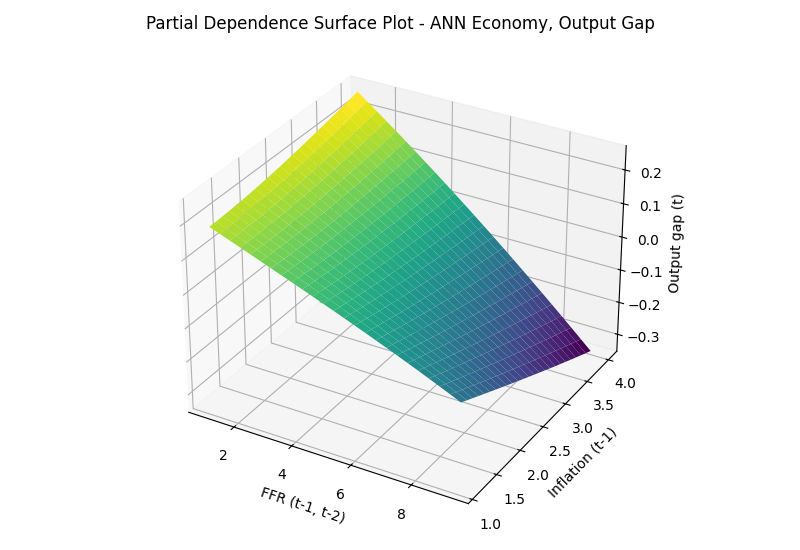

In [34]:
# Output gap surface: y_hat = f(y_lag1, pi_lag1, i_lag1, i_lag2)
# Match paper constraint: i(t-1) = i(t-2)
gx, gy, Z = pd_surface_constrained(
    model=best_y["model"],
    X_raw=X_full_y_raw,
    x_scaler=y_meta["x_scaler"],
    y_scaler=y_meta["y_scaler"],
    feature_cols=y_meta["feature_cols"],
    grid_x_feat="i_lag1",      # FFR (t-1)
    grid_y_feat="pi_lag1",     # Inflation (t-1)
    grid_x_n=25,
    grid_y_n=25,
    sample=2500,
    tie_groups=[("i_lag1", "i_lag2")],  # enforce i(t-1)=i(t-2)
    device="cpu",
)

plot_surface(
    gx, gy, Z,
    xlabel="FFR (t-1, t-2)",
    ylabel="Inflation (t-1)",
    zlabel="Output gap (t)",
    title="Partial Dependence Surface Plot - ANN Economy, Output Gap",
)